#### 0. Setup
We only use 1 file here (proof of concepts)

In [1]:
import torch
Z = torch.load('5_acts_small_layer19_relu_20_20260612_144312/Z_shard000.pt')
print(Z.shape, Z.dtype)
print(f"Size: {Z.element_size() * Z.nelement() / 1e9:.2f} GB")

torch.Size([12288, 16384]) torch.float16
Size: 0.40 GB


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'


#X = torch.load('2_acts_layer19_relu_20_20260610_120821/X_shard000.pt')

Z = torch.load('5_acts_small_layer19_relu_20_20260612_144312/Z_shard000.pt')
Z_mean = Z.float().mean(dim=0)  

Z_active = Z.float()
Z_active[Z_active == 0] = float('nan') # make 0's into nan, so they are not counted by the active_mean (0s do not dilute mean)
active_mean = Z_active.nanmean(dim=0)  # (p)

print(f'Shape of Z: {Z.shape}\nShape of Z mean: {Z_mean.shape}\nShape of Z active: {Z_active.shape}\nShape of Z_active_mean: {active_mean.shape}')


# torch.save(Z_mean, '1_expectation_values.pt')
# torch.save(active_mean, '1_active_expectation_values.pt')


Shape of Z: torch.Size([12288, 16384])
Shape of Z mean: torch.Size([16384])
Shape of Z active: torch.Size([12288, 16384])
Shape of Z_active_mean: torch.Size([16384])


#### 1. Histogram of codes (all, active)

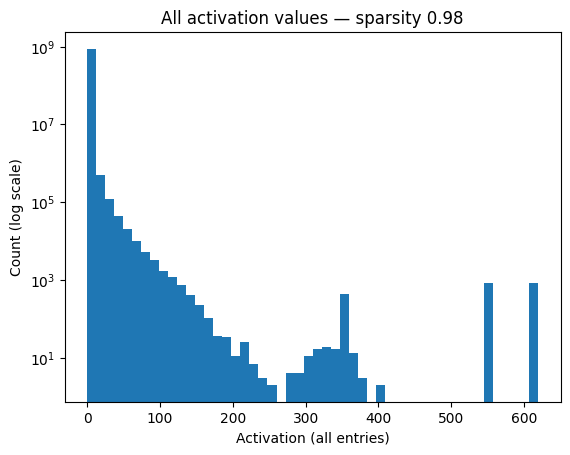

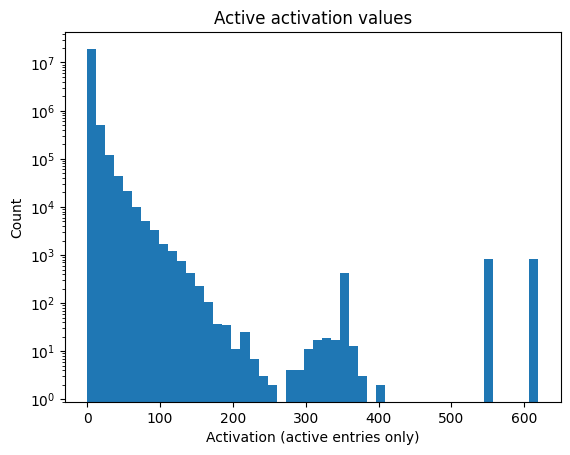

In [ ]:
n_bins = 50

all_counts  = np.zeros(n_bins, dtype=np.int64)
active_counts = np.zeros(n_bins, dtype=np.int64)
total_entries = 0
total_zeros = 0

flat = Z.float().numpy().ravel() # flattens into a 1D array (list?), so that we can use numpy.histogram

# used to calculate sparsity
total_entries += flat.size
total_zeros   += (flat == 0).sum()

values, edges = np.histogram(flat, bins=n_bins) 
# returns the histogram (how many in each bin) as an array, as well as the bin boundaries of len(values)+1
all_counts += values

active = flat[flat > 0]
active_values, _ = np.histogram(active, bins=n_bins)
active_counts += active_values

sparsity = total_zeros / total_entries

plt.figure()
plt.bar(edges[:-1], all_counts, width=np.diff(edges), align='edge', log=True)
plt.xlabel("Activation (all entries)")
plt.ylabel("Count (log scale)")
plt.title(f"All activation values — sparsity {sparsity:.2f}")
#plt.savefig("z_dist.png")
plt.show()
plt.close()

plt.figure()
plt.bar(edges[:-1], active_counts, width=np.diff(edges), align='edge', log=True)
plt.xlabel("Activation (active entries only)")
plt.ylabel("Count (log scale)")
plt.title("Active activation values")
#plt.savefig("z_dist_active.png")
plt.show()
plt.close()

#### 3. Histogram of mean of codes (all, active)

In [ ]:

plt.figure()
plt.hist(Z_mean.numpy(), bins=50)
plt.xlabel('Mean activation (all entries)')
plt.ylabel('Count')
plt.title('Distribution of expectation values')
# plt.savefig('1_histogram1.png')
plt.show()
plt.close()

plt.figure()
active_mean_filtered = active_mean[~torch.isnan(active_mean)]# Boolean mask (removes nans(0s))
plt.hist(active_mean_filtered.numpy(), bins=50)
plt.xlabel('Mean activation (active entries only)')
plt.ylabel('Count')
plt.title('Distribution of active expectation values')
# plt.savefig('1_histogram2.png')
plt.show()
plt.close()

#### 5. Heat map of Gram matrix $Z^TZ$

In [ ]:
def plot_heatmap(mat, title, fname, cmap='RdBu_r', vmin=None, vmax=None):
    plt.figure(figsize=(8, 7))
    im = plt.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax,
                    aspect='auto', interpolation='nearest')
    plt.colorbar(im)
    plt.xlabel('feature $j$')
    plt.ylabel('feature $i$')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.close()
    print(f"Saved {fname}")

for i in range(10):
    print(f"\n--- Shard {i:03d} ---")

    Z = torch.load(f'1_acts_layer12_relu_20_20260610_132348/Z_shard{i:03d}.pt')
    Z = Z.float().to(device)
    n = Z.shape[0]

    Z_centered = Z - Z.mean(dim=0) #
    del Z

    G = Z_centered.T @ Z_centered
    del Z_centered
    G = G.cpu().numpy()

    C = G / (n - 1)
    std = np.sqrt(np.diag(C)).clip(min=1e-8)
    R = C / np.outer(std, std)

    print(f"G  — min: {G.min():.2f}, max: {G.max():.2f}, mean: {G.mean():.2f}")
    print(f"C  — min: {C.min():.4f}, max: {C.max():.4f}, mean: {C.mean():.4f}")
    print(f"R  — min: {R.min():.4f}, max: {R.max():.4f}, mean: {R.mean():.4f}")

    G_masked = G.copy()
    np.fill_diagonal(G_masked, np.nan)
    vmax_G = np.nanpercentile(np.abs(G_masked), 99)
    plot_heatmap(G_masked, f'Centered Gram Matrix — shard {i:03d}',
                 f'1_gram_heatmap_shard{i:03d}.png', vmin=-vmax_G, vmax=vmax_G)

    C_masked = C.copy()
    np.fill_diagonal(C_masked, np.nan)
    vmax_C = np.nanpercentile(np.abs(C_masked), 99)
    plot_heatmap(C_masked, f'Covariance Matrix — shard {i:03d}',
                 f'1_cov_heatmap_shard{i:03d}.png', vmin=-vmax_C, vmax=vmax_C)

    R_masked = R.copy()
    np.fill_diagonal(R_masked, np.nan)
    plot_heatmap(R_masked, f'Correlation Matrix — shard {i:03d}',
                 f'1_corr_heatmap_shard{i:03d}.png', vmin=-1, vmax=1)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [2]:
# Gram = (Z.float().T@Z.float()).numpy()
Gram_test = (Z[:16].float().T@Z[:16].float()).numpy()
heatmap = sns.heatmap(Gram_test)
heatmap.set(xlabel='feature i', ylabel='feature j')

: 

#### 7. Heatmap of centred correlation matrix 
for $i,j$ the (centred) Correlation matrix $C_{i,j}$ is given by: $$C_{i,j} = (\frac{(z-\bar{z}_i)}{||(z-\bar{z}_i)||})^T(\frac{(z-\bar{z}_j)}{||(z-\bar{z}_j)||})$$